[![](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mbanuelos/grad_math_modeling/blob/main/Lectures/Module2_DataSimilarity/11_LinearRegression_GradDescent.ipynb#copy=true)

# MATH 232 - Math Models w/ Tech
## Linear Regression & Gradient Descent
### Instructor: Prof. Mario Bañuelos 

In [1]:
# Import necessary packages
from IPython.display import HTML, Image
import numpy as np
from scipy import linalg as la
from scipy import sparse
import pandas as pd
# import plotting packages
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
import pandas as pd

## Outline

* [Midterm 2 Project](#midterm)
* [Linear Regression as Supervised Learning](#linear)
  * [Model Accuracy](#model-acc)
* [Gradient Descent](#grad)
* [Team Contract Time](#team-contract)
* [Further Reading](#reading)

# Midterm 2 Project Guidelines<a id='midterm 2'></a>

* <a href="https://docs.google.com/document/d/1kVWdWv0Crqc8qua8KGuoC8ok_F_6CRfJtGRM33dUAjw/edit?usp=sharing"> Midterm 2 Project Guidelines </a>
* Team Contract **due 10/17**
* Project Proposal **due 10/24**
* Midterm 2 Project **due 11/9**

# Simple Linear Regression as Supervised Learning <a id='linear'></a>


One of the first methods of supervised learning you may have encountered is the model

$$
Y \approx \beta_0 + \beta_1 X,
$$

where $\beta_0$ is the intercept and $\beta_1$ is the slope. 

Let's simulate some of this data where $X$ is only one-dimensional and we want to predict the quantitative response $Y$.


In [3]:
def simulate_linear(num, b0, b1, random_seed):
    np.random.seed(random_seed)
    # draw samples from a standard normal distribution
    x = np.random.randn(num)
    y = b0 + b1*x
    
    return x,y

In [3]:
def simulate_linear_mb(num, b0, b1, random_seed):
    np.random.seed(random_seed)
    # draw samples from a standard normal distribution
    x = np.random.randn(num)
    y = b0 + b1*x
    
    return x,y

In [4]:
# simulate and plot data
X,Y = simulate_linear(num=800,b0=3,b1=2,random_seed=2)

fig = go.Figure()
fig.add_trace(go.Scatter(x=X,y=Y, mode='markers'))

### Warm-Up 1.

Modify the code above to have 
* $x$ is drawn from a $N(\mu = 10, \sigma^2 = 1)$ distribution
* add some noise (or error) to the simulated data, so that all points do not lie on the line

In [10]:
help(np.random.randn)

Help on built-in function randn:

randn(...) method of numpy.random.mtrand.RandomState instance
    randn(d0, d1, ..., dn)
    
    Return a sample (or samples) from the "standard normal" distribution.
    
    .. note::
        This is a convenience function for users porting code from Matlab,
        and wraps `standard_normal`. That function takes a
        tuple to specify the size of the output, which is consistent with
        other NumPy functions like `numpy.zeros` and `numpy.ones`.
    
    .. note::
        New code should use the ``standard_normal`` method of a ``default_rng()``
        instance instead; please see the :ref:`random-quick-start`.
    
    If positive int_like arguments are provided, `randn` generates an array
    of shape ``(d0, d1, ..., dn)``, filled
    with random floats sampled from a univariate "normal" (Gaussian)
    distribution of mean 0 and variance 1. A single float randomly sampled
    from the distribution is returned if no argument is provided.
 

In [20]:
def simulate_linear_better(num, b0, b1, random_seed):
    # set random seed
    np.random.seed(random_seed)
    # set mean and sd
    mu = 10
    sd = 1
    # draw x from N(mu = 10, sigma = 1)
    x = sd * np.random.randn(num) + mu
    # define the noise!
    noise = np.random.randn(num) 
    # create y based on x and some noise
    y = b0 + b1*x + noise

    return x,y

In [21]:
# simulate and plot data
X,Y = simulate_linear_better(800,3,2,random_seed=2)

fig = go.Figure()
fig.add_trace(go.Scatter(x=X,y=Y, mode='markers'))

Typically, we do not know the values of $\beta$s, so we need to estimate them and our estimates can be written as 

$$
\hat{f} = \hat{y} =\hat{\beta}_0 + \hat{\beta}_1 X,
$$

where $\hat{\beta}_0$ is the *estimated intercept* and $\hat{\beta}_1$ is the *estimated slope*. 

How do we estimate these parameters?


## Assessing Model Accuracy <a id='model-acc'></a>

In regression settings, we can use the *residual sum of squares (RSS)* (generally known as the loss function $\mathcal{L}$), which is defined as

$$
\mathcal{L} = RSS = \sum^{n}_{i=1} \left( y_i - \hat{y_i}\right)^2 = \sum^{n}_{i=1} \left( y_i - \hat{f}(x_i)\right)^2 =  \sum^{n}_{i=1} \left( y_i - [\hat{\beta}_0 + \hat{\beta}_1 x_i]\right)^2
$$

where $\hat{f}(x_i)$ is the prediction that $\hat{f}$ gives for the $i$th observation. 

**Goal:** Minimize the *RSS*! 

How do we minimize quadratic functions?

### Discussion Question.

Calculate $\frac{\partial RSS}{\partial \hat{\beta}_0}$ and $\frac{\partial RSS}{\partial \hat{\beta}_1}$, set them equal to zero and solve for $\hat{\beta}$s.

# Gradient Descent <a id='grad'></a>

A question that arises is how do we estimate the $\hat{\beta}$ values if we cannot set the derivative to zero?

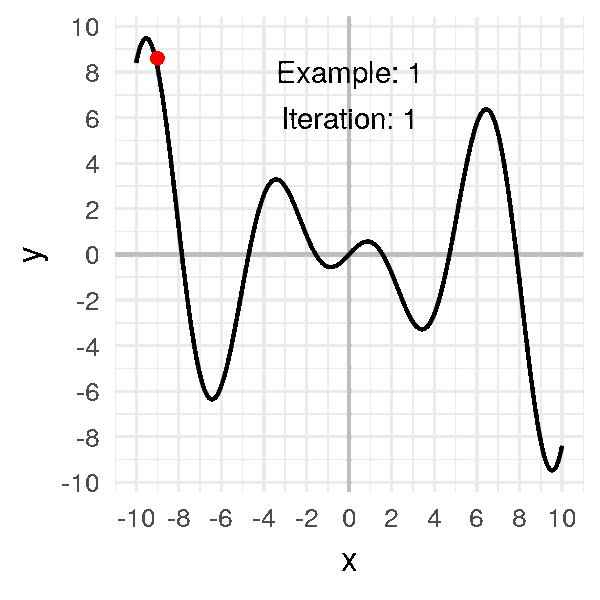

In [22]:
Image('https://www.charlesbordet.com/assets/images/gradient-descent/gradientdescent-f3.gif')

## Gradient Descent Algorithm

0. 
 * Set $\eta$ (the learning rate, also known as step-size)
 * Set number of iterations


 1. Initialize $\hat{\beta}_0$ and $\hat{\beta}_1$
 2. Calculate the partial derivatives of the loss function with respect to the $\hat{\beta}$s
 3. Update $\hat{\beta}_0$ and $\hat{\beta}_1$ by the following rule:
     $$
     \hat{\beta}_0 = \hat{\beta}_{0 (old)} - \eta \times \frac{\mathcal{\partial L}}{\partial \hat{\beta}_0}\\
     \hat{\beta}_1 = \hat{\beta}_{1 (old)} - \eta \times \frac{\mathcal{\partial L}}{\partial \hat{\beta}_1}
     $$
 4. Repeat 1-3 until the number of iterations is reached.


### Discussion Session.

In your groups, write a function that takes in a *loss function gradient, $\eta$,* and the number of iterations $n$, and implements gradient descent. Divide and conquer this problem as follows:

 * one writes the function for the loss function 
 * one (or two) write the function for the gradient of the loss function
 * one person writes the gradient descent function which incorporates the above and plots
 
**Instead of copying and pasting your code**, I encourage you to try <a href="https://codeshare.io/"> codeshare.io </a> so you can all collaborate on the code (... and then all copy it to your notebook). *Note: you do not need to make an account but your code disappears after 24 hours*

# Team Contract Time <a id='team-contract'></a>

* For the remaining time, begin discussing your team contract and potential project topic.

## Further Reading <a id="reading"></a>

* <a href="https://www.charlesbordet.com/en/gradient-descent/#what-to-do-in-case-of-local-minima"> Guide to Gradient Descent in 3 Steps and 12 Drawings </a>
* <a href="https://www.youtube.com/watch?v=AeRwohPuUHQ"> Strang on Gradient Descent </a>
* <a href="http://faculty.marshall.usc.edu/gareth-james/ISL/ISLR%20Seventh%20Printing.pdf"> Introduction to Statistical Learning
</a>